Battery pack degradation dataset:
    cycle_count  avg_charge_rate_C  avg_discharge_temp_C  \
0           100                0.5                    25   
1           300                0.5                    26   
2           600                0.5                    28   
3           900                0.5                    30   
4           150                0.7                    27   
5           350                0.7                    29   
6           650                0.7                    31   
7           950                0.7                    33   
8           200                0.9                    29   
9           400                0.9                    31   
10          700                0.9                    34   
11         1000                0.9                    36   
12          250                1.1                    31   
13          450                1.1                    34   
14          750                1.1                    37   
15    

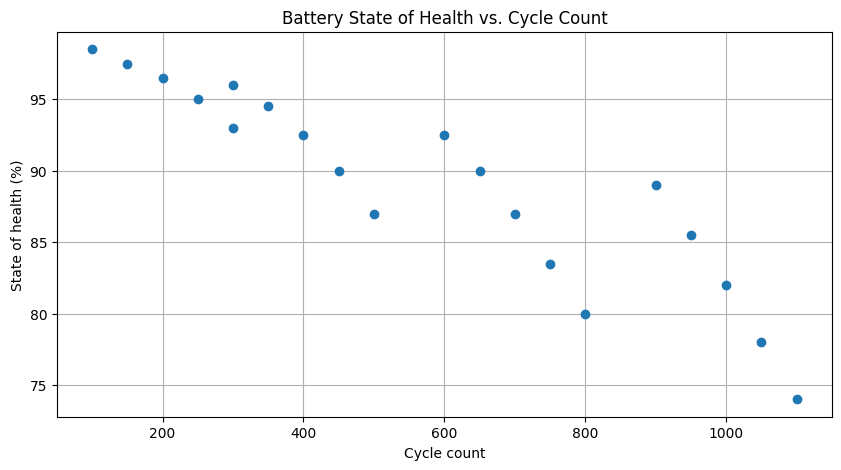


Mean absolute error: 1.63 percentage points

Feature importance:
avg_discharge_temp_C          0.476734
cycle_count                   0.476132
avg_depth_of_discharge_pct    0.035042
avg_charge_rate_C             0.012092
dtype: float64

Predicted state of health: 91.7 %
Fleet decision: Healthy -- no action needed


In [1]:
# ==========================================
# AI-Based EV Battery State of Health (SOH) Prediction
# ==========================================
#
# Where this problem comes from
# ------------------------------
# A core engineering problem for any battery
# maker is tracking how much a cell or pack has degraded from its
# original capacity -- its State of Health -- so packs can be
# warrantied, sorted for second-life use, or flagged for replacement
# before they fail in service.
#
# This script demonstrates predicting SOH (% of original capacity
# remaining) from usage data that a battery management system (BMS)
# would already be logging.
#
# Inputs:  cycle_count, avg_charge_rate_C, avg_discharge_temp_C,
#          avg_depth_of_discharge_pct
# Output:  state_of_health_pct

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# ------------------------------------------
# Battery pack usage / degradation data
# ------------------------------------------

data = {

    "cycle_count": [
        100, 300, 600, 900,
        150, 350, 650, 950,
        200, 400, 700, 1000,
        250, 450, 750, 1050,
        300, 500, 800, 1100
    ],

    "avg_charge_rate_C": [
        0.5, 0.5, 0.5, 0.5,
        0.7, 0.7, 0.7, 0.7,
        0.9, 0.9, 0.9, 0.9,
        1.1, 1.1, 1.1, 1.1,
        1.3, 1.3, 1.3, 1.3
    ],

    "avg_discharge_temp_C": [
        25, 26, 28, 30,
        27, 29, 31, 33,
        29, 31, 34, 36,
        31, 34, 37, 39,
        33, 36, 39, 42
    ],

    "avg_depth_of_discharge_pct": [
        60, 60, 60, 60,
        65, 65, 65, 65,
        70, 70, 70, 70,
        75, 75, 75, 75,
        80, 80, 80, 80
    ],

    "state_of_health_pct": [
        98.5, 96.0, 92.5, 89.0,
        97.5, 94.5, 90.0, 85.5,
        96.5, 92.5, 87.0, 82.0,
        95.0, 90.0, 83.5, 78.0,
        93.0, 87.0, 80.0, 74.0
    ]
}

df = pd.DataFrame(data)

print("Battery pack degradation dataset:")
print(df)

# ------------------------------------------
# Visualize SOH degradation trend
# ------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(df["cycle_count"], df["state_of_health_pct"], marker="o", linestyle="none")

plt.xlabel("Cycle count")

plt.ylabel("State of health (%)")

plt.title("Battery State of Health vs. Cycle Count")

plt.grid()

plt.show()

# ------------------------------------------
# Inputs and outputs
# ------------------------------------------

X = df[
    [
        "cycle_count",
        "avg_charge_rate_C",
        "avg_discharge_temp_C",
        "avg_depth_of_discharge_pct"
    ]
]

y = df["state_of_health_pct"]

# ------------------------------------------
# Split the data
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# ------------------------------------------
# Train the model
# ------------------------------------------

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------
# Evaluate the model
# ------------------------------------------

predictions = model.predict(X_test)

error = mean_absolute_error(y_test, predictions)

print("\nMean absolute error:", round(error, 2), "percentage points")

# ------------------------------------------
# Feature importance
# ------------------------------------------

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature importance:")
print(importances)

# ------------------------------------------
# Predict SOH for a pack currently in service
# ------------------------------------------

pack_in_service = pd.DataFrame({

    "cycle_count": [550],
    "avg_charge_rate_C": [0.8],
    "avg_discharge_temp_C": [30],
    "avg_depth_of_discharge_pct": [68]

})

prediction = model.predict(pack_in_service)[0]

print("\nPredicted state of health:", round(prediction, 1), "%")

# ------------------------------------------
# Turn the prediction into a fleet decision
# ------------------------------------------
# Most EV / stationary-storage warranties treat 80% SOH as the
# end-of-first-life threshold -- below that, a pack is typically
# pulled for second-life use (e.g. stationary storage) or recycling
# rather than kept in the original application.

if prediction >= 90:
    decision = "Healthy -- no action needed"
elif prediction >= 80:
    decision = "Monitor -- approaching end-of-first-life threshold"
else:
    decision = "Below 80% SOH -- flag for second-life reassignment or recycling"

print("Fleet decision:", decision)

Sensor pipeline telemetry dataset:
    frame_rate_fps  signal_dropout_ms  detection_confidence  \
0               30                  0                  0.97   
1               29                  2                  0.95   
2               30                  0                  0.98   
3               30                  1                  0.96   
4               30                  1                  0.94   
5               28                  5                  0.90   
6               22                 40                  0.62   
7               14                120                  0.35   
8               29                  2                  0.95   
9               30                  0                  0.97   
10              30                  1                  0.96   
11              29                  3                  0.94   
12              18                 65                  0.55   
13              30                  0                  0.98   
14              29  

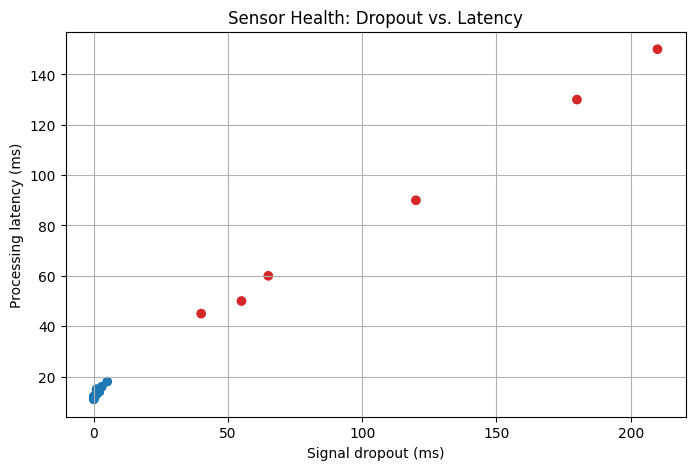


Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

   Anomalous       1.00      1.00      1.00         2
      Normal       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Feature importance:
signal_dropout_ms        0.29
frame_rate_fps           0.25
detection_confidence     0.24
processing_latency_ms    0.22
dtype: float64

Predicted sensor status: Anomalous
Class probabilities:
  Anomalous: 0.98
  Normal: 0.02
Pipeline action: Discard this frame; fall back to redundant sensor input


In [1]:
# ==========================================
# AI-Based Sensor Anomaly Detection
# for Autonomous Vehicle Data Pipelines
# ==========================================
#
# Where this problem comes from
# ------------------------------
# From data-processing solutions for autonomous vehicles --
# turning raw camera/radar/lidar streams into something a self-
# driving stack can safely act on. Before any of that data reaches
# perception or planning software, it has to be checked: a camera
# frame drop, a radar signal dropout, or a sudden confidence-score
# collapse can silently corrupt downstream decisions if it isn't
# caught first.
#
# This script demonstrates that gatekeeping step: classifying each
# incoming sensor reading as Normal or Anomalous before it is trusted
# by the rest of the pipeline.
#
# Inputs:  frame_rate_fps, signal_dropout_ms, detection_confidence,
#          processing_latency_ms
# Output:  sensor_status (Normal / Anomalous)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------
# Simulated sensor pipeline telemetry
# ------------------------------------------

data = {

    "frame_rate_fps": [
        30, 29, 30, 30,
        30, 28, 22, 14,
        29, 30, 30, 29,
        18, 30, 29, 10,
        30, 30, 21, 8
    ],

    "signal_dropout_ms": [
        0, 2, 0, 1,
        1, 5, 40, 120,
        2, 0, 1, 3,
        65, 0, 2, 180,
        0, 1, 55, 210
    ],

    "detection_confidence": [
        0.97, 0.95, 0.98, 0.96,
        0.94, 0.90, 0.62, 0.35,
        0.95, 0.97, 0.96, 0.94,
        0.55, 0.98, 0.95, 0.20,
        0.97, 0.96, 0.58, 0.15
    ],

    "processing_latency_ms": [
        12, 14, 11, 13,
        15, 18, 45, 90,
        14, 12, 13, 16,
        60, 11, 14, 130,
        12, 13, 50, 150
    ],

    "sensor_status": [
        "Normal", "Normal", "Normal", "Normal",
        "Normal", "Normal", "Anomalous", "Anomalous",
        "Normal", "Normal", "Normal", "Normal",
        "Anomalous", "Normal", "Normal", "Anomalous",
        "Normal", "Normal", "Anomalous", "Anomalous"
    ]
}

df = pd.DataFrame(data)

print("Sensor pipeline telemetry dataset:")
print(df)

# ------------------------------------------
# Visualize latency vs. dropout
# ------------------------------------------

plt.figure(figsize=(8, 5))

colors = df["sensor_status"].map({"Normal": "tab:blue", "Anomalous": "tab:red"})

plt.scatter(df["signal_dropout_ms"], df["processing_latency_ms"], c=colors)

plt.xlabel("Signal dropout (ms)")

plt.ylabel("Processing latency (ms)")

plt.title("Sensor Health: Dropout vs. Latency")

plt.grid()

plt.show()

# ------------------------------------------
# Inputs and outputs
# ------------------------------------------

X = df[
    [
        "frame_rate_fps",
        "signal_dropout_ms",
        "detection_confidence",
        "processing_latency_ms"
    ]
]

y = df["sensor_status"]

# ------------------------------------------
# Split the data
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# Train the model
# ------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------
# Evaluate the model
# ------------------------------------------

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nAccuracy:", round(accuracy, 2))
print("\nClassification report:")
print(classification_report(y_test, predictions))

# ------------------------------------------
# Feature importance
# ------------------------------------------

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature importance:")
print(importances)

# ------------------------------------------
# Classify a live sensor reading
# ------------------------------------------

live_reading = pd.DataFrame({

    "frame_rate_fps": [19],
    "signal_dropout_ms": [58],
    "detection_confidence": [0.52],
    "processing_latency_ms": [58]

})

predicted_status = model.predict(live_reading)[0]
status_probabilities = model.predict_proba(live_reading)[0]

print("\nPredicted sensor status:", predicted_status)
print("Class probabilities:")
for label, prob in zip(model.classes_, status_probabilities):
    print(f"  {label}: {round(prob, 2)}")

# ------------------------------------------
# Turn the prediction into a pipeline action
# ------------------------------------------
# This is the part that matters for a real perception stack: an
# "Anomalous" reading shouldn't just be logged, it should change
# what happens next -- e.g. fall back to another sensor, discard the
# frame, or raise a flag for the safety system.

if predicted_status == "Anomalous":
    action = "Discard this frame; fall back to redundant sensor input"
else:
    action = "Pass frame to perception pipeline as normal"

print("Pipeline action:", action)

Sensor pipeline telemetry dataset:
    frame_rate_fps  signal_dropout_ms  detection_confidence  \
0               30                  0                  0.97   
1               29                  2                  0.95   
2               30                  0                  0.98   
3               30                  1                  0.96   
4               30                  1                  0.94   
5               28                  5                  0.90   
6               22                 40                  0.62   
7               14                120                  0.35   
8               29                  2                  0.95   
9               30                  0                  0.97   
10              30                  1                  0.96   
11              29                  3                  0.94   
12              18                 65                  0.55   
13              30                  0                  0.98   
14              29  

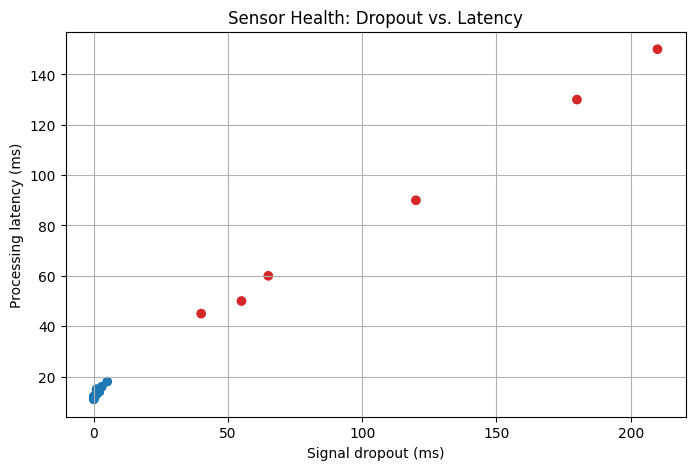


Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

   Anomalous       1.00      1.00      1.00         2
      Normal       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Feature importance:
signal_dropout_ms        0.29
frame_rate_fps           0.25
detection_confidence     0.24
processing_latency_ms    0.22
dtype: float64

Predicted sensor status: Anomalous
Class probabilities:
  Anomalous: 0.98
  Normal: 0.02
Pipeline action: Discard this frame; fall back to redundant sensor input


In [3]:
# ==========================================
# AI-Based Sensor Anomaly Detection
# for Autonomous Vehicle Data Pipelines (Intel-style)
# ==========================================
#
# Where this problem comes from
# ------------------------------
# Intel's Gdansk R&D center is one of Intel's largest globally and
# works on data-processing solutions for autonomous vehicles --
# turning raw camera/radar/lidar streams into something a self-
# driving stack can safely act on. Before any of that data reaches
# perception or planning software, it has to be checked: a camera
# frame drop, a radar signal dropout, or a sudden confidence-score
# collapse can silently corrupt downstream decisions if it isn't
# caught first.
#
# This script demonstrates that gatekeeping step: classifying each
# incoming sensor reading as Normal or Anomalous before it is trusted
# by the rest of the pipeline.
#
# Inputs:  frame_rate_fps, signal_dropout_ms, detection_confidence,
#          processing_latency_ms
# Output:  sensor_status (Normal / Anomalous)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------
# Simulated sensor pipeline telemetry
# ------------------------------------------

data = {

    "frame_rate_fps": [
        30, 29, 30, 30,
        30, 28, 22, 14,
        29, 30, 30, 29,
        18, 30, 29, 10,
        30, 30, 21, 8
    ],

    "signal_dropout_ms": [
        0, 2, 0, 1,
        1, 5, 40, 120,
        2, 0, 1, 3,
        65, 0, 2, 180,
        0, 1, 55, 210
    ],

    "detection_confidence": [
        0.97, 0.95, 0.98, 0.96,
        0.94, 0.90, 0.62, 0.35,
        0.95, 0.97, 0.96, 0.94,
        0.55, 0.98, 0.95, 0.20,
        0.97, 0.96, 0.58, 0.15
    ],

    "processing_latency_ms": [
        12, 14, 11, 13,
        15, 18, 45, 90,
        14, 12, 13, 16,
        60, 11, 14, 130,
        12, 13, 50, 150
    ],

    "sensor_status": [
        "Normal", "Normal", "Normal", "Normal",
        "Normal", "Normal", "Anomalous", "Anomalous",
        "Normal", "Normal", "Normal", "Normal",
        "Anomalous", "Normal", "Normal", "Anomalous",
        "Normal", "Normal", "Anomalous", "Anomalous"
    ]
}

df = pd.DataFrame(data)

print("Sensor pipeline telemetry dataset:")
print(df)

# ------------------------------------------
# Visualize latency vs. dropout
# ------------------------------------------

plt.figure(figsize=(8, 5))

colors = df["sensor_status"].map({"Normal": "tab:blue", "Anomalous": "tab:red"})

plt.scatter(df["signal_dropout_ms"], df["processing_latency_ms"], c=colors)

plt.xlabel("Signal dropout (ms)")

plt.ylabel("Processing latency (ms)")

plt.title("Sensor Health: Dropout vs. Latency")

plt.grid()

plt.show()

# ------------------------------------------
# Inputs and outputs
# ------------------------------------------

X = df[
    [
        "frame_rate_fps",
        "signal_dropout_ms",
        "detection_confidence",
        "processing_latency_ms"
    ]
]

y = df["sensor_status"]

# ------------------------------------------
# Split the data
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# Train the model
# ------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------
# Evaluate the model
# ------------------------------------------

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nAccuracy:", round(accuracy, 2))
print("\nClassification report:")
print(classification_report(y_test, predictions))

# ------------------------------------------
# Feature importance
# ------------------------------------------

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature importance:")
print(importances)

# ------------------------------------------
# Classify a live sensor reading
# ------------------------------------------

live_reading = pd.DataFrame({

    "frame_rate_fps": [19],
    "signal_dropout_ms": [58],
    "detection_confidence": [0.52],
    "processing_latency_ms": [58]

})

predicted_status = model.predict(live_reading)[0]
status_probabilities = model.predict_proba(live_reading)[0]

print("\nPredicted sensor status:", predicted_status)
print("Class probabilities:")
for label, prob in zip(model.classes_, status_probabilities):
    print(f"  {label}: {round(prob, 2)}")

# ------------------------------------------
# Turn the prediction into a pipeline action
# ------------------------------------------
# This is the part that matters for a real perception stack: an
# "Anomalous" reading shouldn't just be logged, it should change
# what happens next -- e.g. fall back to another sensor, discard the
# frame, or raise a flag for the safety system.

if predicted_status == "Anomalous":
    action = "Discard this frame; fall back to redundant sensor input"
else:
    action = "Pass frame to perception pipeline as normal"

print("Pipeline action:", action)

   temperature  vibration    current          rpm  fault
0    49.963210   3.209721  19.934759  1749.175609      0
1    96.057145   3.840142  17.979781  2366.866931      1
2    78.559515   6.850924  10.455388  1906.666952      1
3    67.892679   2.786035  31.148800   708.256458      0
4    32.481491   6.970233  24.877960   963.950592      1


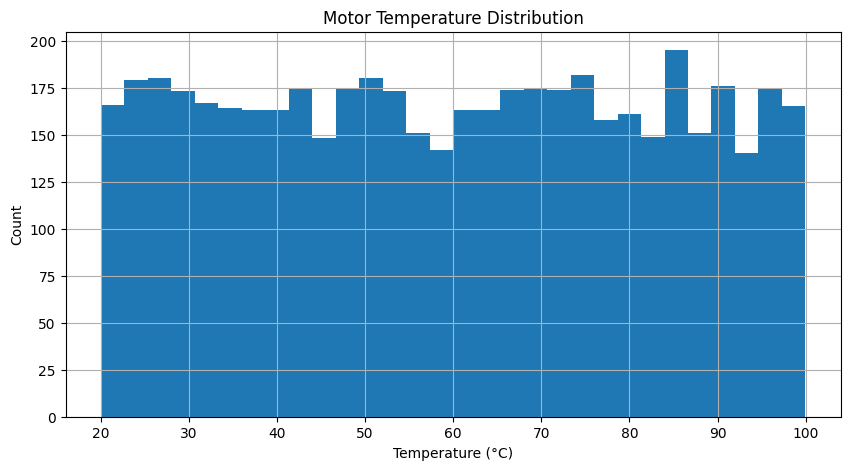


Accuracy:
0.998

Confusion Matrix:
[[347   2]
 [  0 651]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       349
           1       1.00      1.00      1.00       651

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Machine condition: FAULT


In [5]:
# ==================================================
# AI-Based Predictive Maintenance for Industrial Motors
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

# --------------------------------------------------
# Generate industrial sensor data
# --------------------------------------------------

np.random.seed(42)

samples = 5000

temperature = np.random.uniform(20, 100, samples)

vibration = np.random.uniform(0.1, 8.0, samples)

current = np.random.uniform(2, 50, samples)

rpm = np.random.uniform(500, 3000, samples)

fault = (
    (temperature > 75)
    | (vibration > 5)
    | (current > 40)
).astype(int)

df = pd.DataFrame(
    {
        "temperature": temperature,
        "vibration": vibration,
        "current": current,
        "rpm": rpm,
        "fault": fault,
    }
)

print(df.head())

# --------------------------------------------------
# Visualize the data
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(df["temperature"], bins=30)

plt.xlabel("Temperature (°C)")

plt.ylabel("Count")

plt.title("Motor Temperature Distribution")

plt.grid()

plt.show()

# --------------------------------------------------
# Prepare the data
# --------------------------------------------------

X = df[
    [
        "temperature",
        "vibration",
        "current",
        "rpm",
    ]
]

y = df["fault"]

# --------------------------------------------------
# Split the data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# --------------------------------------------------
# Train the model
# --------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
)

# --------------------------------------------------
# Evaluate the model
# --------------------------------------------------

predictions = model.predict(X_test)

print("\nAccuracy:")

print(
    round(
        accuracy_score(
            y_test,
            predictions,
        ),
        3,
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        predictions,
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        predictions,
    )
)

# --------------------------------------------------
# Predict a new motor
# --------------------------------------------------

new_motor = pd.DataFrame(
    {
        "temperature": [82],
        "vibration": [5.5],
        "current": [45],
        "rpm": [2400],
    }
)

prediction = model.predict(
    new_motor
)

if prediction[0] == 1:

    print("\nMachine condition: FAULT")

else:

    print("\nMachine condition: NORMAL")

          vin       vout  load_current  temperature  switching_frequency  \
0  374.908024  41.847417     17.097495    25.103639        137116.856513   
1  490.142861  41.215075     10.395824    77.799142        129045.747435   
2  446.398788  52.083839      4.713847    54.442413        102655.542441   
3  419.731697  59.322326     14.996194    63.522030        123981.898684   
4  331.203728  50.054426      8.954885    75.192844        104764.495317   

   phase_shift  transferred_power  efficiency  
0    19.679571         784.741972   97.146843  
1    13.158148         441.996204   94.977326  
2    10.142062         245.864010   96.000175  
3    18.162802         962.226144   96.124210  
4    16.096480         475.557959   95.163737  


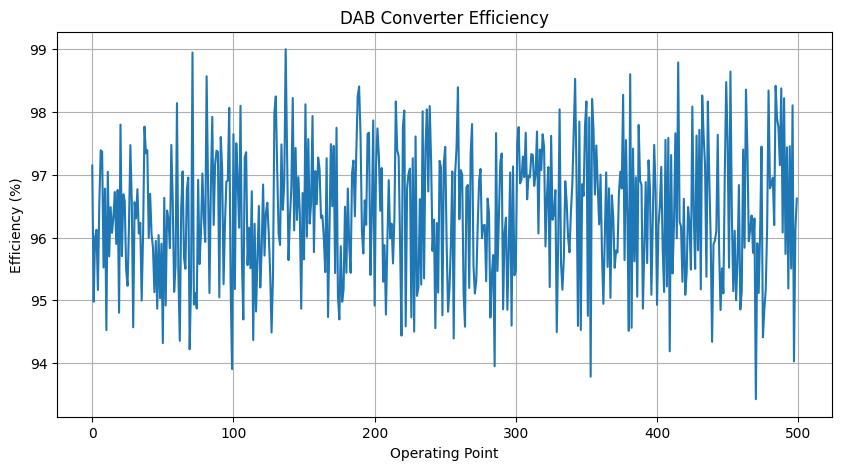

Training completed.

Mean Absolute Error: 0.421
R² Score: 0.987


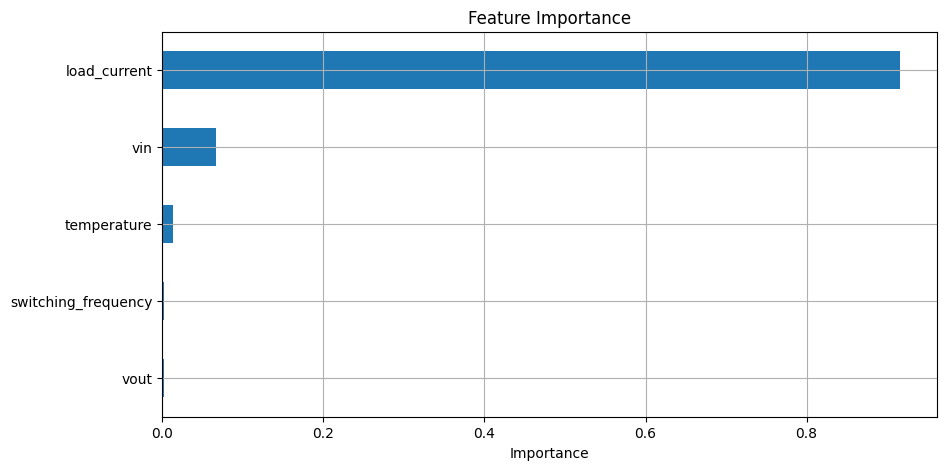


Predicted phase shift: 11.72 degrees
MOSFET gate delay: 0.271 microseconds


In [6]:
# ==========================================================
# AI-Based Modeling and Control of a Dual Active Bridge Converter
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# Generate converter operating points
# ----------------------------------------------------------

np.random.seed(42)

n_samples = 25000

vin = np.random.uniform(300, 500, n_samples)

vout = np.random.uniform(40, 60, n_samples)

load_current = np.random.uniform(1, 20, n_samples)

temperature = np.random.uniform(25, 80, n_samples)

switching_frequency = np.random.uniform(
    50000,
    200000,
    n_samples
)

# ----------------------------------------------------------
# Simulated converter behavior
# ----------------------------------------------------------

phase_shift = (
    6
    + 0.8 * load_current
    - 0.02 * (vin - 400)
    + 0.03 * (temperature - 40)
    + np.random.normal(0, 0.5, n_samples)
)

transferred_power = (
    vout
    * load_current
    * (0.9 + phase_shift / 100)
)

efficiency = (
    97
    - 0.0001 * (vin - 400) ** 2
    - 0.04 * load_current
    - 0.03 * (temperature - 40)
    + 0.00002 * (switching_frequency - 100000)
    + np.random.normal(0, 0.3, n_samples)
)

efficiency = np.clip(
    efficiency,
    85,
    99
)

# ----------------------------------------------------------
# Create the dataset
# ----------------------------------------------------------

df = pd.DataFrame(
    {
        "vin": vin,
        "vout": vout,
        "load_current": load_current,
        "temperature": temperature,
        "switching_frequency": switching_frequency,
        "phase_shift": phase_shift,
        "transferred_power": transferred_power,
        "efficiency": efficiency,
    }
)

print(df.head())

# ----------------------------------------------------------
# Visualize efficiency
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df["efficiency"][:500]
)

plt.xlabel("Operating Point")

plt.ylabel("Efficiency (%)")

plt.title("DAB Converter Efficiency")

plt.grid()

plt.show()

# ----------------------------------------------------------
# Prepare the features
# ----------------------------------------------------------

X = df[
    [
        "vin",
        "vout",
        "load_current",
        "temperature",
        "switching_frequency",
    ]
]

# ----------------------------------------------------------
# Target: phase shift
# ----------------------------------------------------------

y = df["phase_shift"]

# ----------------------------------------------------------
# Split the data
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------------------------------------
# Train the model
# ----------------------------------------------------------

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ----------------------------------------------------------
# Evaluate the model
# ----------------------------------------------------------

predictions = model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print(
    "\nMean Absolute Error:",
    round(mae, 3)
)

print(
    "R² Score:",
    round(r2, 3)
)

# ----------------------------------------------------------
# Feature importance
# ----------------------------------------------------------

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(10, 5))

importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.grid()

plt.show()

# ----------------------------------------------------------
# Predict a new operating point
# ----------------------------------------------------------

new_operating_point = pd.DataFrame(
    {
        "vin": [420],
        "vout": [48],
        "load_current": [8],
        "temperature": [45],
        "switching_frequency": [120000],
    }
)

predicted_phase = model.predict(
    new_operating_point
)

print(
    "\nPredicted phase shift:",
    round(predicted_phase[0], 2),
    "degrees"
)

# ----------------------------------------------------------
# Gate delay calculation
# ----------------------------------------------------------

frequency = 120000

period = 1 / frequency

gate_delay = (
    period
    * predicted_phase[0]
    / 360
)

print(
    "MOSFET gate delay:",
    round(gate_delay * 1e6, 3),
    "microseconds"
)